# Exploratory Data Analysis — Lahore AQI

Five point seven years of hourly weather, pollutant concentrations and computed
EPA AQI, read straight from the Hopsworks feature store.

The purpose is not a tour of the columns. Each section below answers a question
that changed a modelling decision, and the decision is stated with it. The
single most consequential finding is in section 3.

In [1]:
import sys
from pathlib import Path

# Kernels differ on what they use as cwd -- the notebook's folder under
# nbconvert, the workspace root in some editors -- so walk up to whichever
# directory holds the packages instead of assuming either.
REPO_ROOT = next(
    parent for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "feature_pipeline").is_dir()
)
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv

load_dotenv(REPO_ROOT / ".env")

from feature_pipeline.aqi import _CATEGORIES, aqi_category
from feature_pipeline.hopsworks_store import read_features_df

# Colors (validated categorical/sequential palette)
BLUE = "#2a78d6"
ORANGE = "#eb6834"
AQUA = "#1baf7a"
YELLOW = "#eda100"
MAGENTA = "#e87ba4"
GREEN = "#008300"
VIOLET = "#4a3aa7"
RED = "#e34948"
CATEGORICAL = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED]

INK = "#0b0b0b"
MUTED = "#898781"
GRID = "#e1e0d9"
SURFACE = "#fcfcfb"

plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": MUTED,
        "axes.labelcolor": INK,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "text.color": INK,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 11,
        "figure.dpi": 110,
    }
)

## 1. What is actually in the store

Row count, span, and the two integrity checks that matter for a forecasting
target: duplicate timestamps (which would double-count an hour) and missing
hours (which decide whether labels can be built by row position).

In [2]:
df = read_features_df().sort_values("timestamp").reset_index(drop=True)
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

span_hours = int((df["timestamp"].max() - df["timestamp"].min()) / pd.Timedelta(hours=1)) + 1
duplicates = int(df["timestamp"].duplicated().sum())
missing_hours = span_hours - len(df)

print(f"rows            : {len(df):,}")
print(f"span            : {df['timestamp'].min()} -> {df['timestamp'].max()}")
print(f"expected hours  : {span_hours:,}")
print(f"missing hours   : {missing_hours:,}  ({missing_hours / span_hours:.1%})")
print(f"duplicate stamps: {duplicates}")
print(f"nulls           : {int(df.isna().sum().sum())}")
print(f"columns         : {len(df.columns)}")
df.head(3)

2026-08-25 09:13:49,000 INFO: Initializing external client


2026-08-25 09:13:49,001 INFO: Base URL: https://eu-west.cloud.hopsworks.ai:443


2026-08-25 09:13:50,713 INFO: Python Engine initialized.



Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/41084


Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (2.37s) 
rows            : 49,153
span            : 2020-11-27 00:00:00+00:00 -> 2026-08-15 02:00:00+00:00
expected hours  : 50,091
missing hours   : 938  (1.9%)
duplicate stamps: 0
nulls           : 0
columns         : 23


,city_name,timestamp,hour,day,month,temp,feels_like,humidity,pressure,wind_speed,...,no,no2,o3,so2,pm2_5,pm10,nh3,dominant_pollutant,aqi,aqi_change_rate
0,Lahore,2020-11-27 00:00:00+00:00,0,27,11,10.3,8.3,89,996,2.95,...,0.00,18.34,43.99,6.32,83.23,103.26,3.58,pm2_5,170,0.0
1,Lahore,2020-11-27 01:00:00+00:00,1,27,11,10.1,8.0,90,996,3.11,...,0.01,21.08,40.05,7.03,87.24,107.03,3.83,pm2_5,173,3.0
2,Lahore,2020-11-27 02:00:00+00:00,2,27,11,10.0,7.8,90,996,3.36,...,0.14,34.27,26.82,9.42,101.58,125.56,6.59,pm2_5,183,10.0


**Decision this drove.** Hours are missing, so the 24/48/72h label for a row is
matched by *timestamp arithmetic*, never by shifting a fixed number of rows. A
positional shift across a gap pairs a row with the wrong future value and raises
no error — see `training_pipeline/data.py::add_target`.

2026-08-25 09:13:56,472 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-08-25 09:13:56,473 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


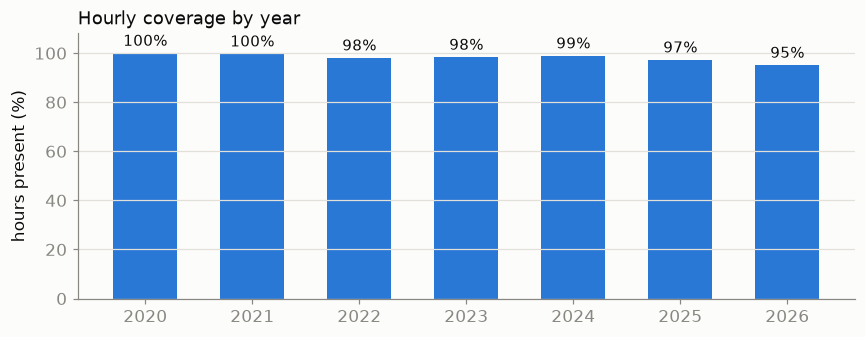

In [3]:
per_year = df.assign(year=df["timestamp"].dt.year).groupby("year")
coverage = pd.DataFrame(
    {
        "rows": per_year.size(),
        "expected": per_year["timestamp"].agg(
            lambda s: int((s.max() - s.min()) / pd.Timedelta(hours=1)) + 1
        ),
    }
)
coverage["coverage"] = coverage["rows"] / coverage["expected"]

fig, ax = plt.subplots(figsize=(8, 3.2))
bars = ax.bar(coverage.index.astype(str), coverage["coverage"] * 100, color=BLUE, width=0.6)
for bar, value in zip(bars, coverage["coverage"] * 100):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 1.5, f"{value:.0f}%",
            ha="center", va="bottom", color=INK, fontsize=10)
ax.set_ylim(0, 108)
ax.set_ylabel("hours present (%)")
ax.set_title("Hourly coverage by year", loc="left", fontsize=12)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

## 2. The AQI series

Hourly AQI is too dense to read directly, so the daily mean is drawn with a
30-day rolling mean over it. Both are the same measure on the same axis.

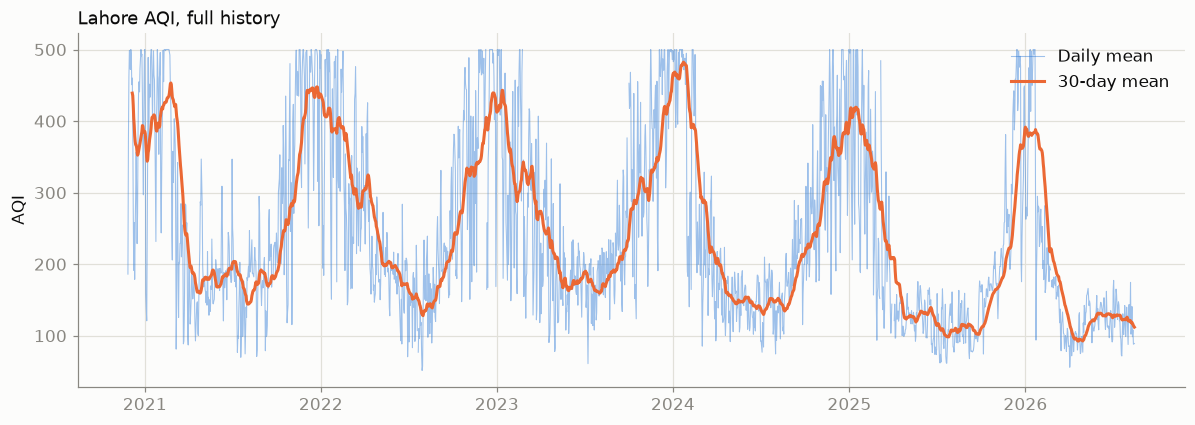

count    49153.0
mean       243.3
std        141.2
min         15.0
25%        147.0
50%        189.0
75%        313.0
max        500.0


In [4]:
series = df.set_index("timestamp")["aqi"]
daily = series.resample("D").mean()
rolling = daily.rolling(30, min_periods=10).mean()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(daily.index, daily.values, color=BLUE, linewidth=0.7, alpha=0.45, label="Daily mean")
ax.plot(rolling.index, rolling.values, color=ORANGE, linewidth=2, label="30-day mean")
ax.set_ylabel("AQI")
ax.set_title("Lahore AQI, full history", loc="left", fontsize=12)
ax.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()

print(series.describe().round(1).to_string())

Two features of this plot drive everything downstream: a strong annual cycle
(winter smog), and a downward drift across years. The next two sections separate
them, because they have opposite implications for the model.

## 3. The finding that shaped the whole project — pollution is falling

Mean AQI by calendar year. This is not seasonal noise: it is a sustained decline.

2026-08-25 09:13:56,880 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-08-25 09:13:56,881 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


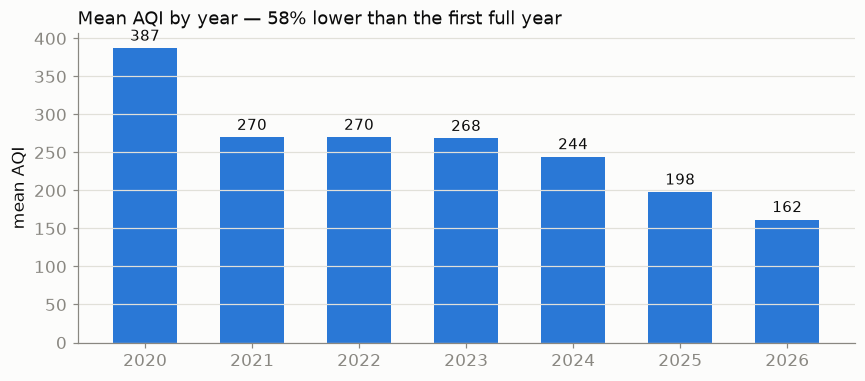

timestamp
2020    387.0
2021    270.0
2022    270.0
2023    268.0
2024    244.0
2025    198.0
2026    162.0


In [5]:
yearly = series.groupby(series.index.year).mean()
decline = (yearly.iloc[0] - yearly.iloc[-1]) / yearly.iloc[0]

fig, ax = plt.subplots(figsize=(8, 3.6))
bars = ax.bar(yearly.index.astype(str), yearly.values, color=BLUE, width=0.6)
for bar, value in zip(bars, yearly.values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 5, f"{value:.0f}",
            ha="center", va="bottom", color=INK, fontsize=10)
ax.set_ylabel("mean AQI")
ax.set_title(f"Mean AQI by year — {decline:.0%} lower than the first full year",
             loc="left", fontsize=12)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

print(yearly.round(0).to_string())

**Decision this drove — the most important one in the project.** A model trained
across all years learns the average of a *dirtier era* and systematically
over-predicts today. Tree models make this worse: they cannot extrapolate below
the levels they saw in training.

So the models do not predict the AQI level at all. They predict the **change**
from the latest reading, and the forecast is anchored to it:

```
prediction = current_aqi + w · predicted_delta
```

Anchoring tracks the falling level for free, because `current_aqi` is today's
actual measurement. This is also why a single frozen train/test split flatters
linear models — a stale model cannot follow a trend, and linear models
extrapolate — and why the project evaluates walk-forward instead.

## 4. Seasonality, separated from the trend

Year down, month across, mean AQI as the fill. A single-hue sequential ramp,
because the quantity is magnitude with no meaningful midpoint.

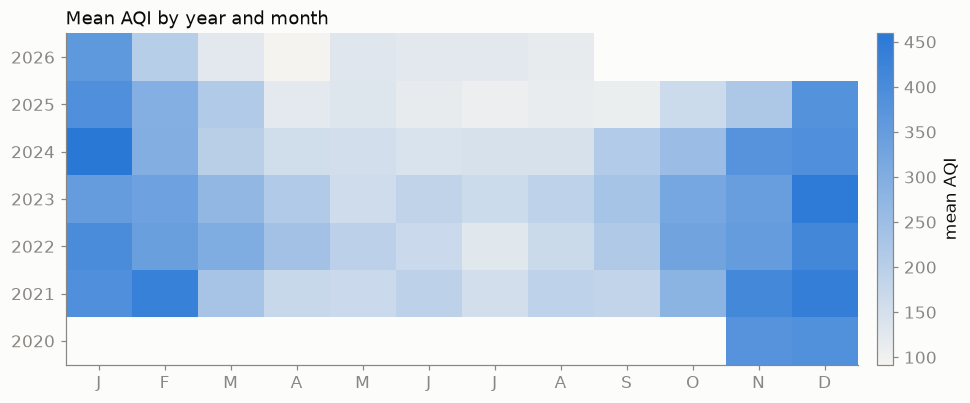

month
1     392.0
2     320.0
3     225.0
4     168.0
5     158.0
6     155.0
7     137.0
8     158.0
9     191.0
10    269.0
11    343.0
12    411.0


In [6]:
from matplotlib.colors import LinearSegmentedColormap

by_year_month = (
    df.assign(year=df["timestamp"].dt.year, month=df["timestamp"].dt.month)
    .pivot_table(index="year", columns="month", values="aqi", aggfunc="mean")
)

sequential = LinearSegmentedColormap.from_list("surface_to_blue", ["#f4f3f0", BLUE])

fig, ax = plt.subplots(figsize=(9.5, 3.8))
mesh = ax.pcolormesh(by_year_month.columns, by_year_month.index, by_year_month.values,
                     cmap=sequential, shading="nearest")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])
ax.set_yticks(by_year_month.index)
ax.set_ylabel("")
ax.set_title("Mean AQI by year and month", loc="left", fontsize=12)
ax.grid(visible=False)
fig.colorbar(mesh, ax=ax, label="mean AQI", pad=0.02)
plt.tight_layout()
plt.show()

print(df.assign(month=df["timestamp"].dt.month).groupby("month")["aqi"].mean().round(0).to_string())

Winter (November–January) is far worse than summer, consistently, in every year.
Reading the rows top to bottom shows the decline of section 3 running through the
seasonal pattern rather than replacing it.

**Decision this drove.** The test window must span whole seasons. An earlier
evaluation used three weeks of stable summer as its test set and reported error
around MAE 19; a test window covering a winter reports around MAE 48 for the same
kind of model. The second number is not a regression — it is the honest one.

## 5. Daily cycle

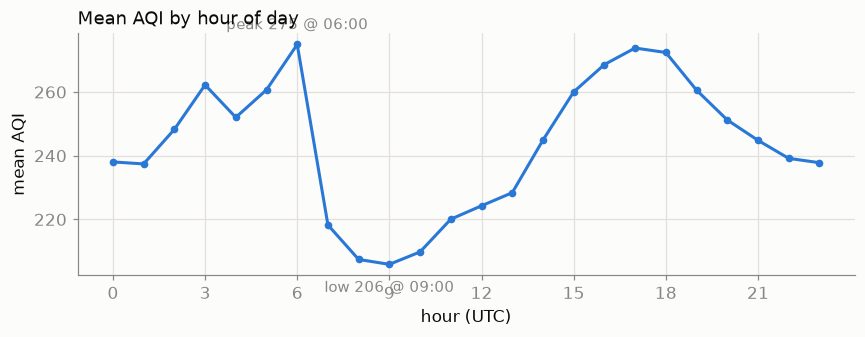

In [7]:
hourly_profile = df.groupby(df["timestamp"].dt.hour)["aqi"].mean()

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(hourly_profile.index, hourly_profile.values, color=BLUE, linewidth=2, marker="o", markersize=4)
peak, trough = hourly_profile.idxmax(), hourly_profile.idxmin()
for hour, label in ((peak, "peak"), (trough, "low")):
    ax.annotate(f"{label} {hourly_profile[hour]:.0f} @ {hour:02d}:00",
                (hour, hourly_profile[hour]), textcoords="offset points",
                xytext=(0, 10 if label == "peak" else -18), ha="center", color=MUTED, fontsize=10)
ax.set_xticks(range(0, 24, 3))
ax.set_xlabel("hour (UTC)")
ax.set_ylabel("mean AQI")
ax.set_title("Mean AQI by hour of day", loc="left", fontsize=12)
plt.tight_layout()
plt.show()

**Decision this drove.** `hour` is kept as a feature and encoded cyclically
(`sin`/`cos`) so 23:00 and 00:00 sit next to each other rather than at opposite
ends of a 0–23 range. `day`-of-month and `month` are computed and stored in the
feature group, but are **excluded from the model's feature set**: with only three
months of data they let the model memorise "late July looks like this", and with
the full history they measurably hurt (R² 0.628 vs 0.645 at 24h).

## 6. Why the naive baseline is so hard to beat

Autocorrelation of hourly AQI. The dashed lines mark the three forecast horizons.

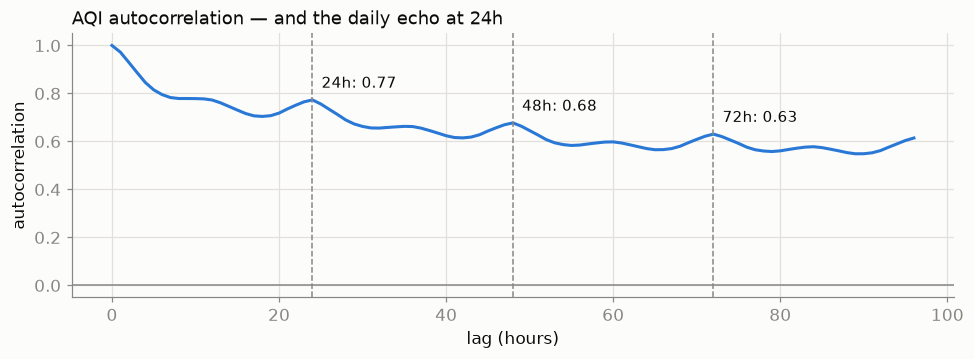

In [8]:
from statsmodels.tsa.stattools import acf

regular = series.asfreq("h").interpolate(limit=6)
lags = 96
values = acf(regular.dropna(), nlags=lags, fft=True)

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(range(lags + 1), values, color=BLUE, linewidth=2)
for horizon in (24, 48, 72):
    ax.axvline(horizon, color=MUTED, linestyle="--", linewidth=1)
    ax.annotate(f"{horizon}h: {values[horizon]:.2f}", (horizon, values[horizon]),
                textcoords="offset points", xytext=(6, 8), color=INK, fontsize=10)
ax.axhline(0, color=MUTED, linewidth=1)
ax.set_xlabel("lag (hours)")
ax.set_ylabel("autocorrelation")
ax.set_title("AQI autocorrelation — and the daily echo at 24h", loc="left", fontsize=12)
plt.tight_layout()
plt.show()

AQI at `t + 24h` is strongly correlated with AQI at `t`, and there is a visible
echo at multiples of 24 hours from the daily cycle.

**Decision this drove.** "Assume no change" is a strong forecast here, so
**persistence is scored alongside every model, every time**. It scores R² 0.814 /
0.709 / 0.628 at 24/48/72h and beat every standalone model tried in this project.
A result not compared against it is not a result. The deployed forecast is a
blend of the model with persistence, which is what finally beat it.

## 7. How much time is spent in each EPA category

Share of hours per year, coloured with the official EPA/AirNow palette — a status
scale, not a categorical one, so the colours carry the same meaning as the
dashboard's alerts.

2026-08-25 09:13:58,201 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-08-25 09:13:58,202 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-08-25 09:13:58,206 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-08-25 09:13:58,210 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-08-25 09:13:58,213 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-08-25 09:13:58,217 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-08-25 09:13:58,222 INFO: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


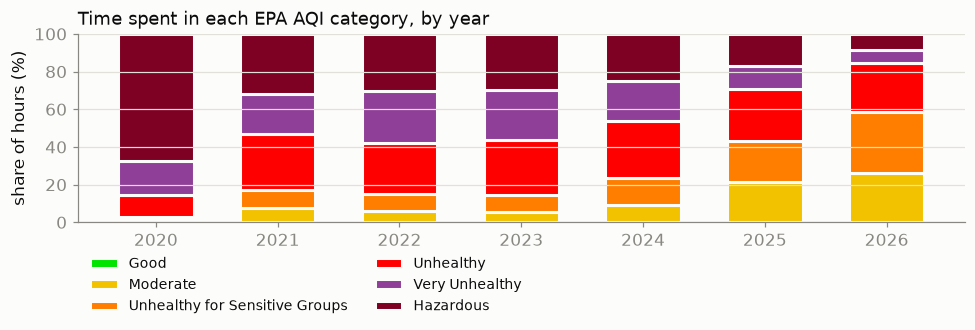

category  Good  Moderate  Unhealthy for Sensitive Groups  Unhealthy  Very Unhealthy  Hazardous
year                                                                                          
2020       0.0       1.3                             1.5       11.4            18.5       67.3
2021       0.0       7.3                             9.5       30.0            21.5       31.7
2022       0.4       5.4                             9.4       27.0            27.3       30.4
2023       0.2       5.2                             9.1       29.2            26.3       30.0
2024       0.0       9.0                            14.4       30.4            21.3       24.9
2025       0.2      21.1                            21.9       27.4            12.1       17.3
2026       0.2      26.0                            32.6       25.8             6.9        8.6


In [9]:
category_names = [name for _, _, name, _, _ in _CATEGORIES]
category_colors = {name: color for _, _, name, _, color in _CATEGORIES}

labelled = df.assign(
    year=df["timestamp"].dt.year,
    category=pd.Categorical(
        [aqi_category(value)[0] for value in df["aqi"]], categories=category_names, ordered=True
    ),
)
shares = (
    labelled.pivot_table(index="year", columns="category", values="aqi", aggfunc="size", observed=False)
    .fillna(0)
)
shares = shares.div(shares.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 3.8))
bottom = np.zeros(len(shares))
for name in category_names:
    if name not in shares:
        continue
    ax.bar(shares.index.astype(str), shares[name], bottom=bottom, width=0.62,
           color=category_colors[name], label=name, edgecolor=SURFACE, linewidth=2)
    bottom += shares[name].to_numpy()
ax.set_ylabel("share of hours (%)")
ax.set_ylim(0, 100)
ax.set_title("Time spent in each EPA AQI category, by year", loc="left", fontsize=12)
ax.legend(frameon=False, fontsize=9, ncol=2, loc="lower left", bbox_to_anchor=(0, -0.55))
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

print(shares.round(1).to_string())

Hazardous and Very Unhealthy hours shrink over the years, which is the decline of
section 3 expressed in the units the dashboard actually alerts on.

**Decision this drove.** Alert thresholds are read from the same
`aqi_category()` table that produces these colours, so the alert boundaries and
the AQI scale cannot disagree.

## 8. Which features carry signal

Correlation of every numeric column with AQI. Sorted, so the ordering is the
message.

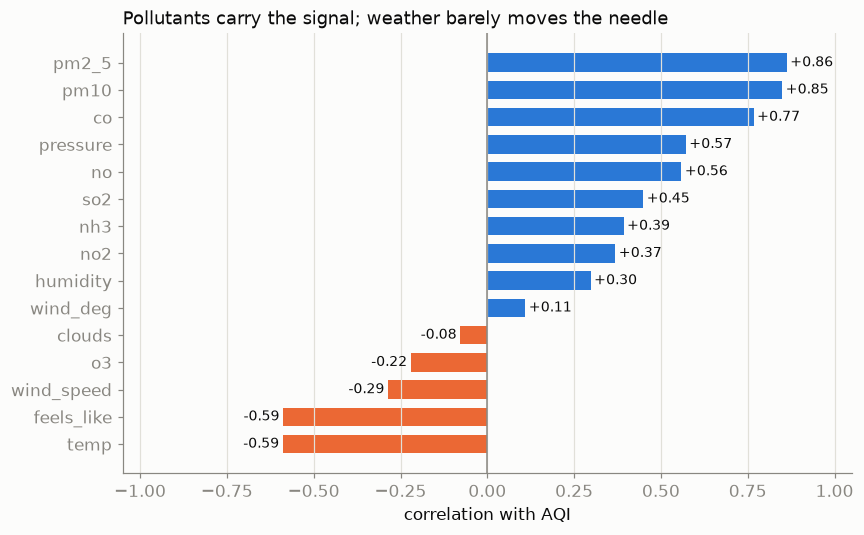

In [10]:
feature_columns = [
    "pm2_5", "pm10", "co", "no2", "so2", "o3", "no", "nh3",
    "temp", "feels_like", "humidity", "pressure", "wind_speed", "wind_deg", "clouds",
]
correlations = df[feature_columns + ["aqi"]].corr()["aqi"].drop("aqi").sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = [BLUE if value >= 0 else ORANGE for value in correlations]
bars = ax.barh(correlations.index, correlations.values, color=colors, height=0.68)
for bar, value in zip(bars, correlations.values):
    offset = 0.01 if value >= 0 else -0.01
    ax.text(value + offset, bar.get_y() + bar.get_height() / 2, f"{value:+.2f}",
            va="center", ha="left" if value >= 0 else "right", color=INK, fontsize=9)
ax.axvline(0, color=MUTED, linewidth=1)
ax.set_xlim(-1.05, 1.05)
ax.set_xlabel("correlation with AQI")
ax.set_title("Pollutants carry the signal; weather barely moves the needle", loc="left", fontsize=12)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

PM2.5 dominates — it is the pollutant that sets the AQI in the large majority of
hours, which the `dominant_pollutant` column confirms below. Weather correlates
weakly.

**Decision this drove.** Weather features were kept, but the weak correlation was
an early signal that they carry less than hoped. It was confirmed later:
supplying *forecast* weather as features made every horizon worse (24h R² 0.718 →
0.695; 72h 0.519 → 0.368), so that idea was dropped rather than kept because it
sounded sophisticated.

In [11]:
dominant = df["dominant_pollutant"].value_counts(normalize=True) * 100
print("Dominant pollutant, share of hours:")
print(dominant.round(1).to_string())

Dominant pollutant, share of hours:
dominant_pollutant
pm2_5    89.2
o3       10.4
pm10      0.4
co        0.0


## 9. Train and test are drawn from different distributions

A chronological 80/20 split, with the AQI distribution of each side. This is the
regime shift of section 3, in the form the model actually meets it.

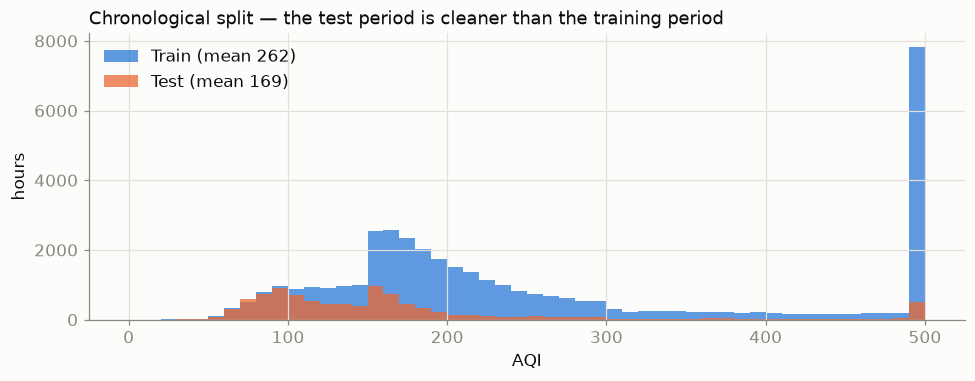

train: 2020-11-27 -> 2025-06-20  mean 261.9  std 142.4
test : 2025-06-20 -> 2026-08-15  mean 169.3  std 108.8


In [12]:
split_at = int(len(df) * 0.8)
train_aqi = df["aqi"].iloc[:split_at]
test_aqi = df["aqi"].iloc[split_at:]

fig, ax = plt.subplots(figsize=(9, 3.6))
bins = np.linspace(0, 500, 51)
ax.hist(train_aqi, bins=bins, color=BLUE, alpha=0.75, label=f"Train (mean {train_aqi.mean():.0f})")
ax.hist(test_aqi, bins=bins, color=ORANGE, alpha=0.75, label=f"Test (mean {test_aqi.mean():.0f})")
ax.set_xlabel("AQI")
ax.set_ylabel("hours")
ax.set_title("Chronological split — the test period is cleaner than the training period",
             loc="left", fontsize=12)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print(f"train: {df['timestamp'].iloc[0].date()} -> {df['timestamp'].iloc[split_at - 1].date()}"
      f"  mean {train_aqi.mean():.1f}  std {train_aqi.std():.1f}")
print(f"test : {df['timestamp'].iloc[split_at].date()} -> {df['timestamp'].iloc[-1].date()}"
      f"  mean {test_aqi.mean():.1f}  std {test_aqi.std():.1f}")

The test period is both cleaner and less variable. A model fitted on the left
distribution and scored on the right one is being asked to predict a level it has
never seen, which is exactly the task production never faces — production
retrains daily and forecasts 24–72 hours.

**Decision this drove.** Evaluation is walk-forward: retrain at successive
monthly origins and score only the following month. The same model scores 0.738
under a single frozen split and 0.831 walk-forward at 24h. Changing the
evaluation also changed which model wins — under the frozen split Ridge came
first, under walk-forward gradient boosting does.

## Summary

| Finding | Consequence in the code |
|---|---|
| Hours are missing | Labels matched by timestamp, never by row shift |
| Mean AQI has fallen sharply since the first year | Models predict the *change* in AQI, anchored to the latest reading |
| Strong annual cycle | Test windows must span seasons; summer-only test sets flatter the model |
| Clear daily cycle | `hour` kept and cyclically encoded; `day`/`month` stored but excluded |
| AQI is highly autocorrelated | Persistence scored against every candidate; the deployed forecast blends with it |
| PM2.5 dominates, weather is weak | Forecast-weather features tested and rejected on measurement |
| Train and test distributions differ | Walk-forward evaluation instead of one frozen split |

Full chronology, including the hypotheses that failed, is in
[`../docs/EXPERIMENT_LOG.md`](../docs/EXPERIMENT_LOG.md).